In [3]:
from fastai.vision.all import *

In [4]:
from make import load_heathy_data
from pathlib import Path
import os

spec = load_heathy_data()


Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 3 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1

In [5]:
len(spec)

1820

In [6]:
from validation_util import split

valid_spec = split(spec, int(len(spec) * 0.1))

In [7]:
print(f'Initial shape of a spectrogram: ', spec[0].shape)

ch, freq_bins = spec[0].shape

ratio = 1800/6400
cutoff_idx = int(freq_bins * ratio) # idx to cut the spectrogram
final_shape = (ch, cutoff_idx)
print(f'Final shape: {final_shape}')

Initial shape of a spectrogram:  (129, 35)
Final shape: (129, 9)


In [8]:
# constants you can tweak once
FLOOR_DB   = -5.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [9]:
def get_x(i):
    arr = spec[i]

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr.shape) == 3:
            arr = np.mean(arr, axis=-1)  # average across channels
    
    #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)

In [10]:
block = DataBlock(
    blocks=(TransformBlock(), TransformBlock()),
    splitter=RandomSplitter(valid_pct=0.2),
    get_items=lambda x: x,
    get_x=get_x,
    get_y=get_x,
)

In [11]:
items = list(range(len(spec)))   # or `range(N)`
dls = block.dataloaders(items, bs=8)

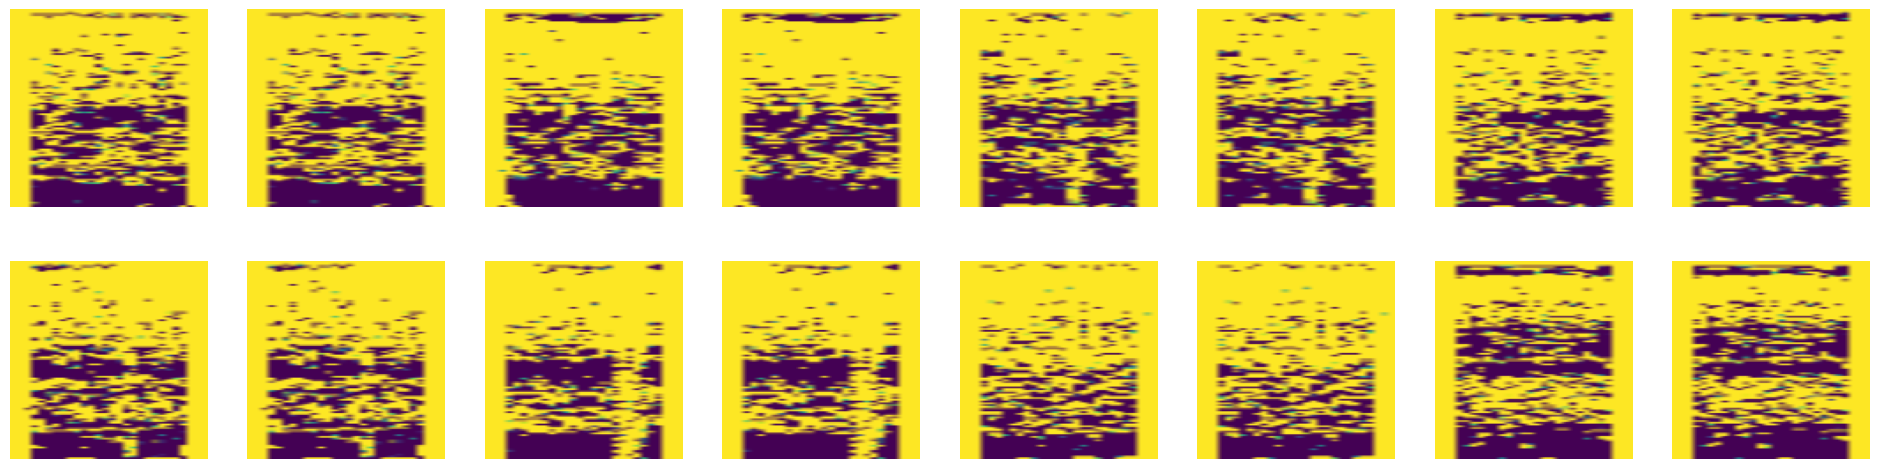

In [12]:
dls.show_batch()

In [13]:
import torch
import torch.nn as nn


class Experimental(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(

            nn.Conv2d(3, 8, kernel_size=4, stride=2),     # (8, 59, 59)
            nn.ReLU(),
            
            nn.Conv2d(8, 16, kernel_size=3, stride=2),     # (16, 29, 29)
            nn.ReLU(),
        
            nn.Conv2d(16, 32, kernel_size=3, stride=2),    # (32, 14, 14)
            nn.ReLU(),
        
            nn.Conv2d(32, 64, kernel_size=3, stride=2),    # (64, 6, 6)
            nn.ReLU(),

        )
    
    
        # ---------- Bottleneck ----------
        self.bottleneck = nn.Sequential(
            nn.Flatten(),                       # [B, 128, 2, 2] → [B, 512]
            nn.Linear(64 * 6 * 6, 64), nn.ReLU(),
            nn.Linear(64, 64 * 6 * 6),  
            nn.Unflatten(1, (64, 6, 6))        # back to [B, 128, 2, 2]
        )
    
        # ---------- Decoder ----------
        self.decoder = nn.Sequential(
    
            # 6 × 6 → 13 × 13
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2),
            nn.ReLU(),
    
            # 13 × 13 → 27 × 27
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2),
            nn.ReLU(),
    
            # 27 × 27 → 55 × 55
            nn.ConvTranspose2d(16, 8, kernel_size=3, stride=2),
            nn.ReLU(),
    
            # 55 × 55 → 112 × 112
            nn.ConvTranspose2d(8, 3, kernel_size=4, stride=2),
            nn.Sigmoid()                         # pixel values in [0, 1]
        )
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.bottleneck(x)
        x = self.decoder(x)
        return x
    
    def to_device(self, device):
        """Move model to specified device"""
        self.to(device)
        return self
    
    @property
    def device(self):
        """Get the device the model is on"""
        return next(self.parameters()).device

In [14]:
autoencoder = Experimental()

In [15]:
learner = Learner(dls, autoencoder, loss_func=F.mse_loss)

epoch,train_loss,valid_loss,time
0,0.049828,0.039104,00:01
1,0.038544,0.038705,00:01
2,0.037726,0.037648,00:01
3,0.037891,0.037436,00:01
4,0.037669,0.037976,00:01
5,0.037860,0.037484,00:01
6,0.037692,0.037973,00:01
7,0.037586,0.037490,00:01
8,0.037628,0.037771,00:01
9,0.037781,0.037307,00:01


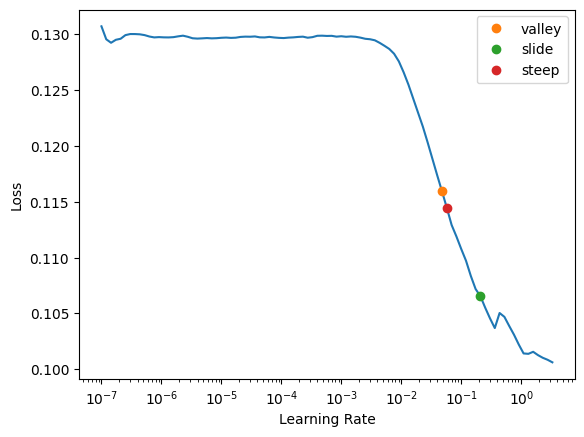

In [16]:
lr = learner.lr_find(suggest_funcs=(valley,slide,steep))
learner.fit_one_cycle(n_epoch = 25, lr_max=lr.valley)

In [17]:
learner.validate()

(#1) [0.03708825632929802]

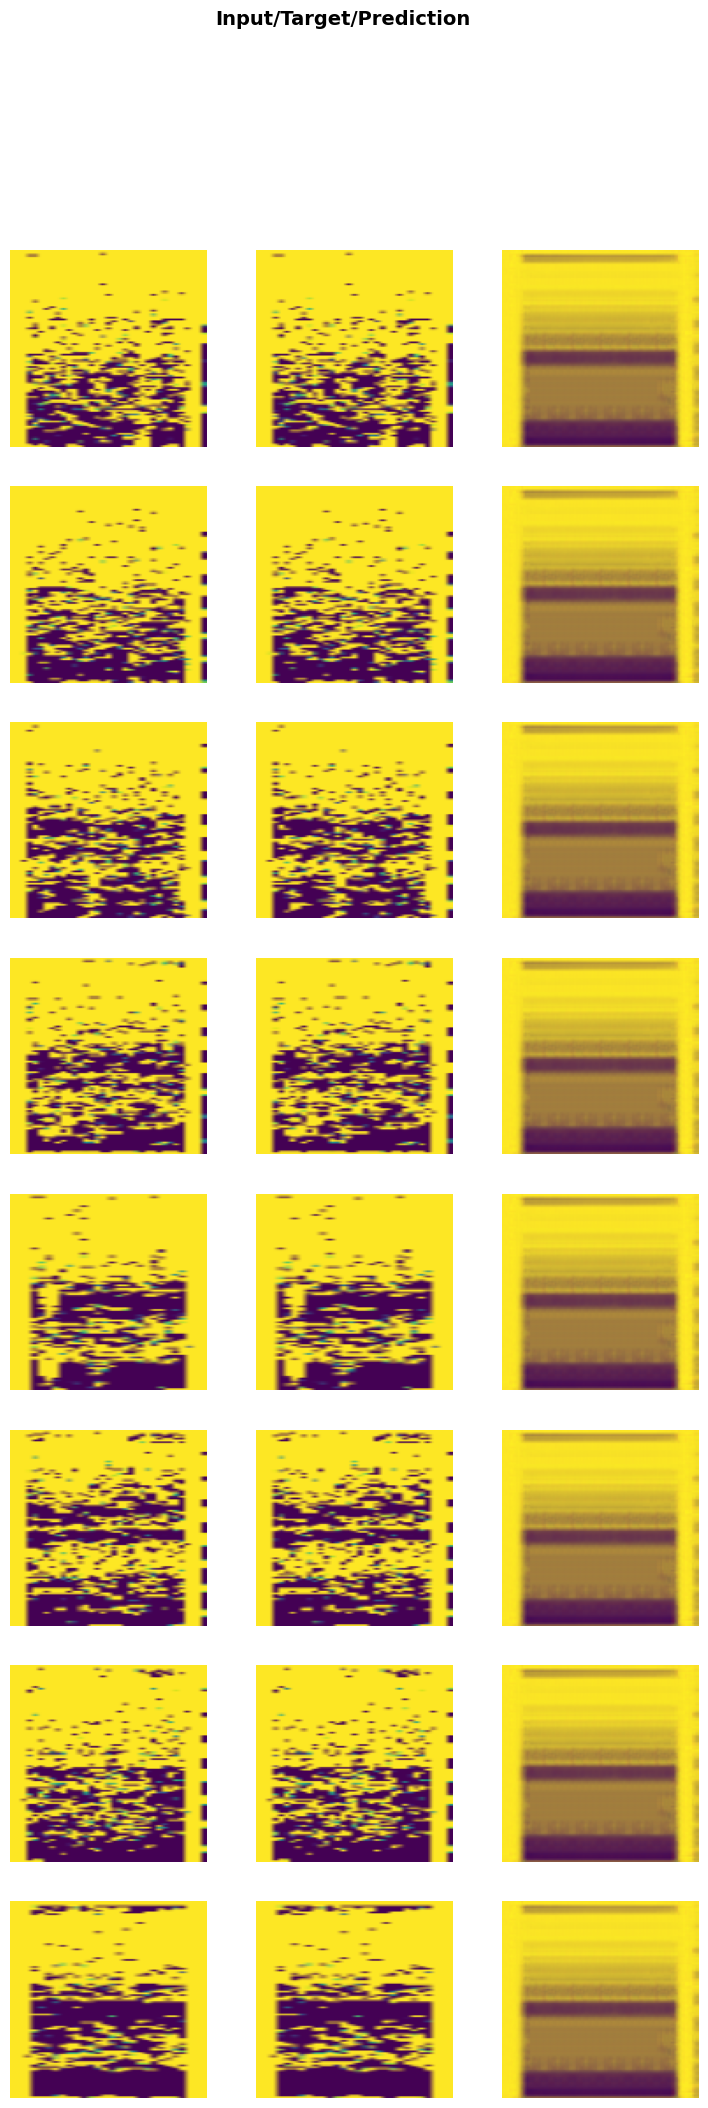

In [18]:
learner.show_results()

In [19]:
from make import load_primary_data
from validation_util import get_label_index

test_spec, test_labels = load_primary_data()

Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: F

In [20]:
get_label_index("Fall", test_labels)

0

In [22]:
def get_x_test(i):
    arr = test_spec[i]

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr.shape) == 3:
            arr = np.mean(arr, axis=-1)  # average across channels
    
    #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)

In [23]:
block = DataBlock(
    blocks=(TransformBlock(), TransformBlock()),
    get_items=lambda x: x,
    get_x=get_x_test,
    get_y=get_x_test,
)

In [24]:
items = list(range(len(test_spec)))   # or `range(N)`
test_dls = block.dataloaders(items, bs=8)

In [25]:
preds, targets = learner.get_preds(dl=test_dls)

In [26]:
preds.shape

torch.Size([960, 3, 112, 112])

In [27]:
targets.shape

torch.Size([960, 3, 112, 112])

In [28]:
F.mse_loss(preds, targets)

tensor(0.0408)

In [29]:
F.l1_loss(preds, targets)

tensor(0.1284)

In [30]:
from kornia.metrics import psnr

psnr_value = psnr(preds, targets, max_val=1.0)

In [31]:
psnr_value

tensor(13.8944)

In [1]:
from validation_util import get_label_index

In [34]:
get_label_index("Fall", test_labels)

0

In [36]:
pred_tensor = learner.predict(get_x_test(0))[0]

<Axes: >

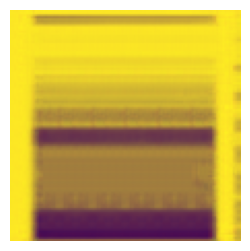

In [37]:
pred_tensor.show()

In [38]:
F.mse_loss(pred_tensor, get_x_test(0))

TensorImage(0.0387)

<Axes: >

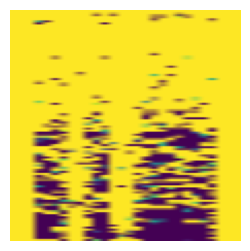

In [39]:
get_x_test(0).show()

In [40]:
psnr(pred_tensor, get_x_test(0))

TensorImage(14.1254)

## Reconstrcution 
- The Peak signal to noise ratio (psnr) is a metric that shows how well the model can reconstruct details.
- The psnr is low, indicating that the model cannot reconstruct the images very well.
- mse (mean squared error) is a metric to see how far from the origional the reconstruction is. 
- As there is no difference in the mse from reconstructing heathly vs unhealthy images is a key
- We see that the psnr is low, it fails to reconstruct the input accurately, indicating that the model did not learn to reconstruct the healty data.
- Reason: Theory is a too narrow dataset, with too much variation. Not a good fit for this application. 